# Observation Model

The `observe()` function takes Covasim’s simulated infection results (`new_infections`) and generates **observed diagnoses** and **observed sequencing counts**.  

## How the Function Works

### 1) Load true infections from Covasim
- `sim.results['new_infections']` provides the number of actual infections per day.
- This represents the “true epidemic curve” before any observation or reporting bias.

### 2) Initialize arrays for observed data
- `new_diag`: daily observed diagnoses  
- `new_seq`: daily observed sequences  
Both start at zero and are filled through probabilistic sampling.

### 3) Sample who gets tested
For each day:
- Let `n` be the number of new infections.
- A fraction `p_test` of infected individuals receive a diagnostic test.
- This is modeled using a binomial draw:  
  `n_diag ~ Binomial(n, p_test)`.

### 4) Apply reporting delay
- Diagnosed individuals are distributed across future days according to `delay_pmf`.
- This uses a multinomial draw:  
  `diag_by_delay ~ Multinomial(n_diag, delay_pmf)`.
- Example: if `delay_pmf = [0.05, 0.15, 0.30, ...]`, then  
  5% are diagnosed on the same day,  
  15% after 1 day,  
  30% after 2 days, etc.

### 5) Ignore diagnoses that fall outside the simulation window
- If `day + k >= T`, those diagnoses are dropped.

### 6) Sample sequencing among diagnosed individuals
- For each diagnosis count on a given day,  
  `seq ~ Binomial(count, p_seq)`  
  determines how many are sequenced.

### 7) Compute and print cumulative totals
- `np.cumsum(new_diag)[-1]` → total observed diagnoses  
- `np.cumsum(new_seq)[-1]` → total observed sequences  

These provide a quick summary of the observation model output.

## How This Differs from Covasim’s Diagnosis Logic

Covasim’s diagnosis system works at the individual (agent) level. Each person has symptoms, testing behavior, test sensitivity, and a built‑in test delay. Symptomatic and asymptomatic people have different testing probabilities, and interventions like isolation or contact tracing can change who gets tested and when results appear.

In contrast, the `observe()` function is a simplified, aggregate‑level observation model. It does not track individuals. Instead, it takes daily infection counts and applies a single testing probability, a user‑defined delay distribution, and a fixed sequencing probability. It ignores symptoms, test sensitivity, and agent‑level behavior.

In short: Covasim models how diagnoses actually happen, while `observe()` models how many of those infections would be observed after under‑reporting and delays.


In [1]:
import sys
sys.path.append("/home/jhkim/covasim_project/jhk_covasim4wastewater")

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.13 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.16 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.20 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.23 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.28 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.32 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.37 s)  •••••••••••••••••••• 100%

Simulation summary:
        1,503 cumulative infections
           17 cumulative reinfections
        1,183 cumulative infectious
          731 cumulative symptomatic cases
           47 cumulative severe cases
           15 cumulative critical cases
          706 cumulative recoveries
            4 cumulative deaths
          685 cumulative tests
          685 cumulative diagnoses
            4 cumulative known deaths
            0 cumulative quarantined people
          685 cumulative isolated peo

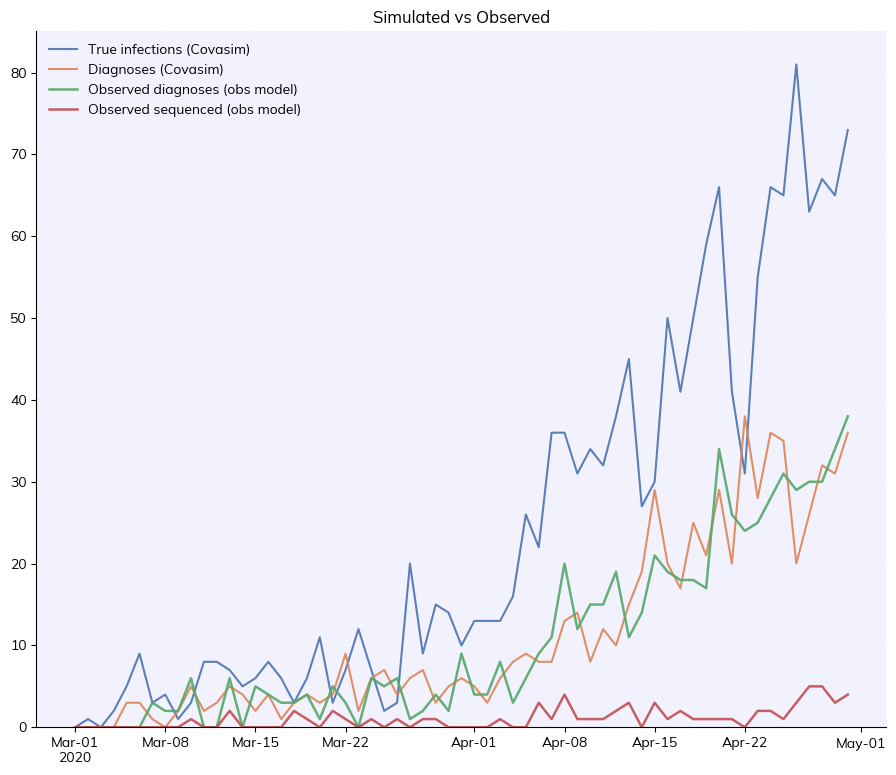

In [3]:
import covasim as cv
import numpy as np
from observation_model import observe, plot_sim_vs_observed

p_test = 0.5
p_seq = 0.1

interv = cv.test_prob(symp_prob=p_test)
sim = cv.Sim(interventions=[interv])
sim.run()

new_diag, new_seq = observe(sim, p_test, p_seq, [0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03])

plot_sim_vs_observed(sim, new_diag, new_seq)

When we set Covasim’s symptomatic testing probability (symp_prob) to 0.5 and, in parallel, configured the observation model with the same testing probability (p_test = 0.5), we observe that the two diagnosis curves show very similar trends.

## Set delay_pmf = [1]

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.16 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.20 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.24 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.28 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.33 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.37 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.41 s)  •••••••••••••••••••• 100%

Simulation summary:
        1,503 cumulative infections
           17 cumulative reinfections
        1,183 cumulative infectious
          731 cumulative symptomatic cases
           47 cumulative severe cases
           15 cumulative critical cases
          706 cumulative recoveries
            4 cumulative deaths
          685 cumulative tests
          685 cumulative diagnoses
            4 cumulative known deaths
            0 cumulative quarantined people
          685 cumulative isolated peo

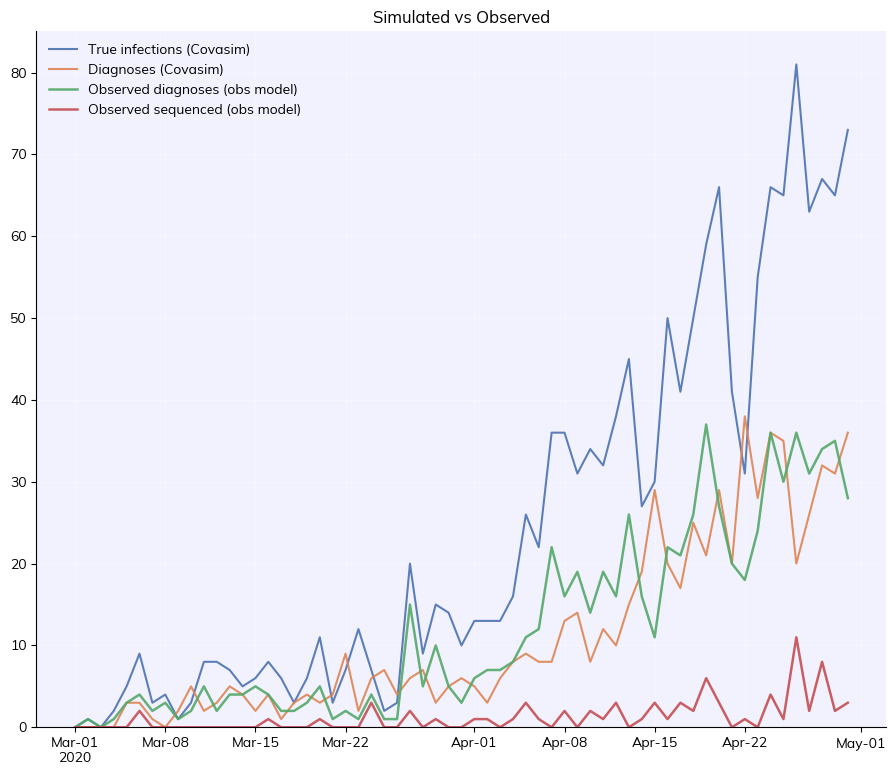

In [11]:
import covasim as cv
import numpy as np
from observation_model import observe, plot_sim_vs_observed

p_test = 0.5
p_seq = 0.1

interv = cv.test_prob(symp_prob=p_test)
sim = cv.Sim(interventions=[interv])
sim.run()

new_diag, new_seq = observe(sim, p_test, p_seq, [1])

plot_sim_vs_observed(sim, new_diag, new_seq)

## Set different p_test

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.33 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.41 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.46 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.52 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.58 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.64 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.72 s)  •••••••••••••••••••• 100%

Simulation summary:
        5,966 cumulative infections
          128 cumulative reinfections
        4,640 cumulative infectious
        3,021 cumulative symptomatic cases
          178 cumulative severe cases
           49 cumulative critical cases
        2,459 cumulative recoveries
           11 cumulative deaths
      119,805 cumulative tests
        2,270 cumulative diagnoses
            9 cumulative known deaths
            0 cumulative quarantined people
        2,270 cumulative isolated peo

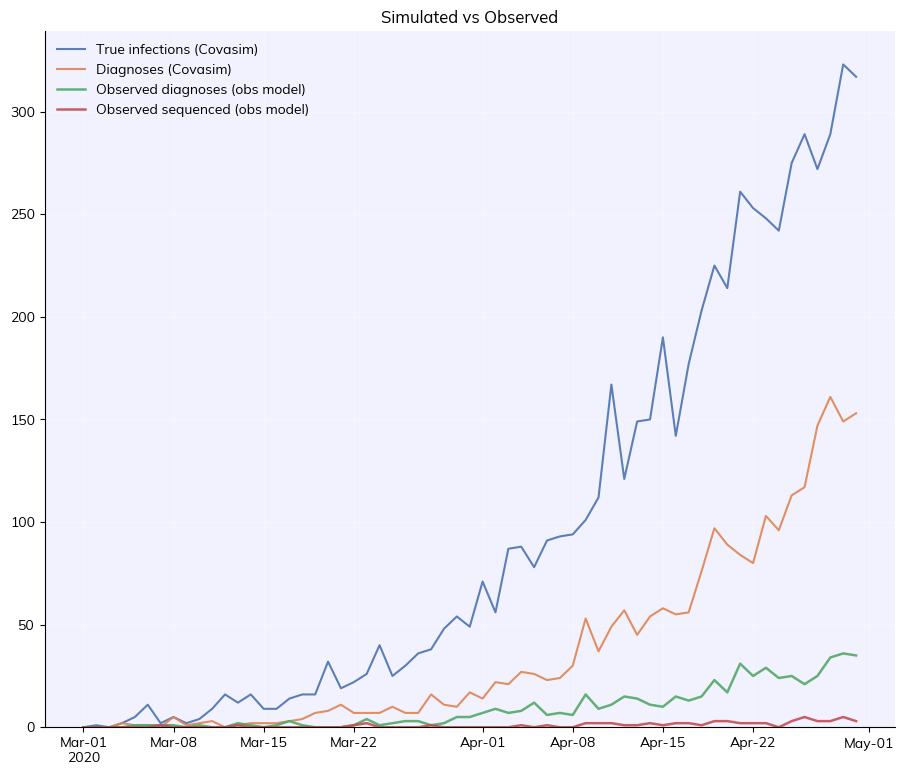

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.18 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.22 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.27 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.32 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.37 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.42 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.48 s)  •••••••••••••••••••• 100%

Simulation summary:
          857 cumulative infections
            4 cumulative reinfections
          690 cumulative infectious
          467 cumulative symptomatic cases
           25 cumulative severe cases
            4 cumulative critical cases
          422 cumulative recoveries
            0 cumulative deaths
      242,245 cumulative tests
          513 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
          513 cumulative isolated peo

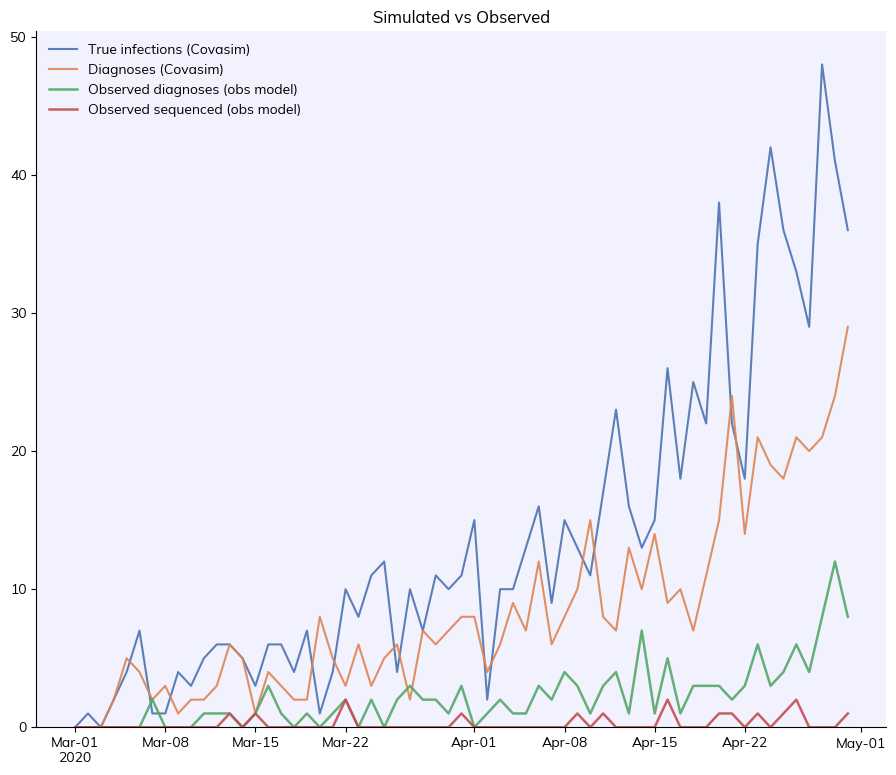

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.18 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.24 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.30 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.35 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.40 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.45 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.51 s)  •••••••••••••••••••• 100%

Simulation summary:
          560 cumulative infections
            3 cumulative reinfections
          500 cumulative infectious
          334 cumulative symptomatic cases
           25 cumulative severe cases
            5 cumulative critical cases
          380 cumulative recoveries
            0 cumulative deaths
      363,682 cumulative tests
          451 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
          451 cumulative isolated peo

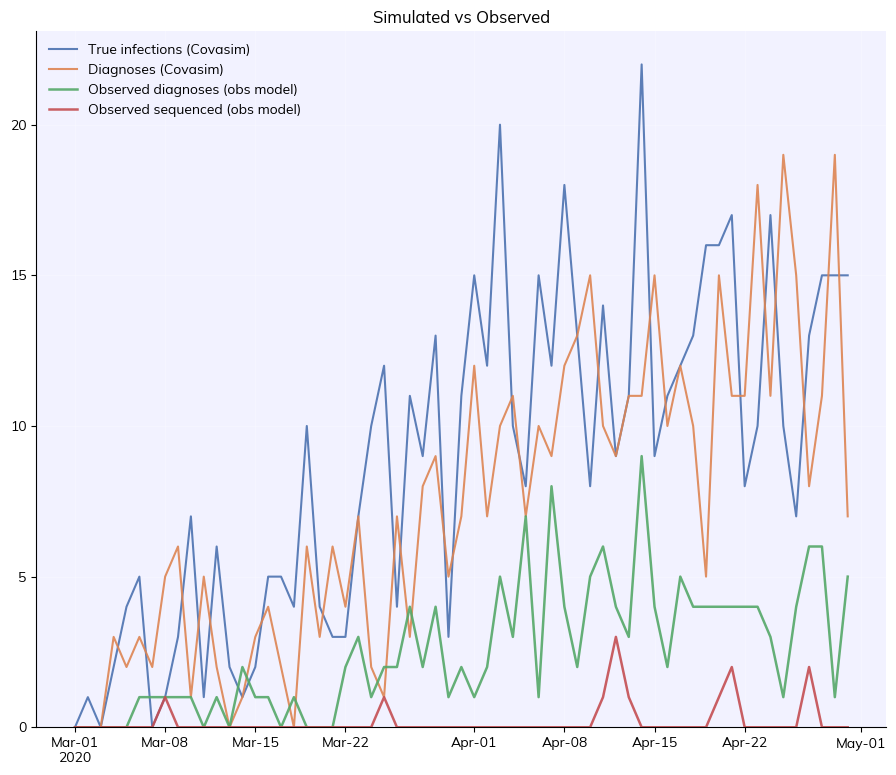

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.17 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.22 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.28 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.34 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.40 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.44 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.49 s)  •••••••••••••••••••• 100%

Simulation summary:
           61 cumulative infections
            0 cumulative reinfections
           60 cumulative infectious
           40 cumulative symptomatic cases
            6 cumulative severe cases
            0 cumulative critical cases
           55 cumulative recoveries
            0 cumulative deaths
      487,346 cumulative tests
           60 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
           60 cumulative isolated peo

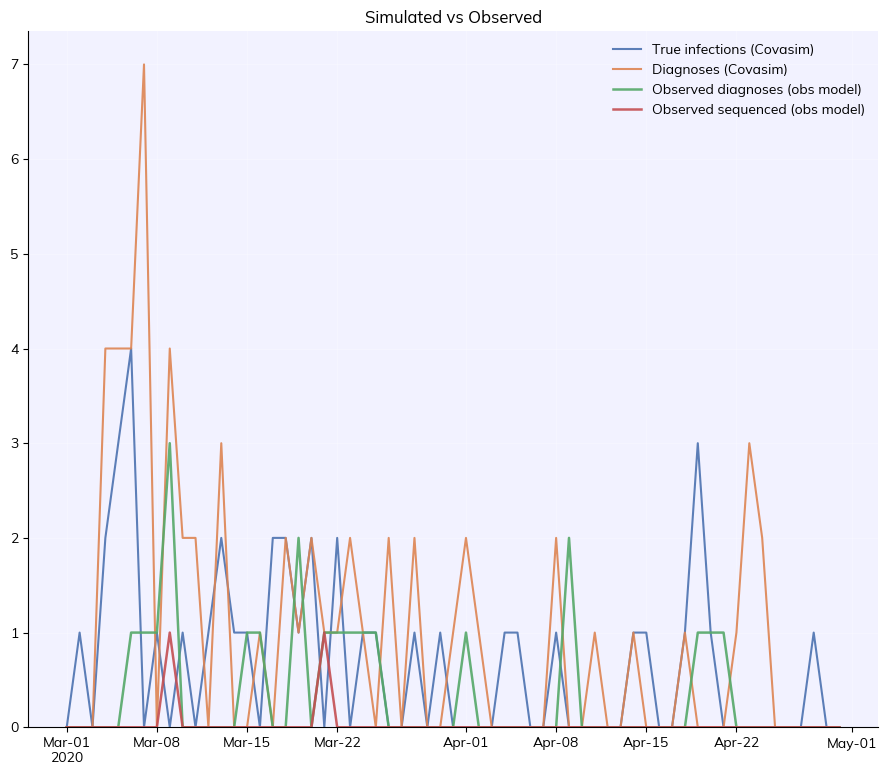

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.16 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.21 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.26 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.30 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.35 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.39 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.44 s)  •••••••••••••••••••• 100%

Simulation summary:
           48 cumulative infections
            0 cumulative reinfections
           48 cumulative infectious
           31 cumulative symptomatic cases
            6 cumulative severe cases
            1 cumulative critical cases
           46 cumulative recoveries
            1 cumulative deaths
      609,174 cumulative tests
           48 cumulative diagnoses
            1 cumulative known deaths
            0 cumulative quarantined people
           48 cumulative isolated peo

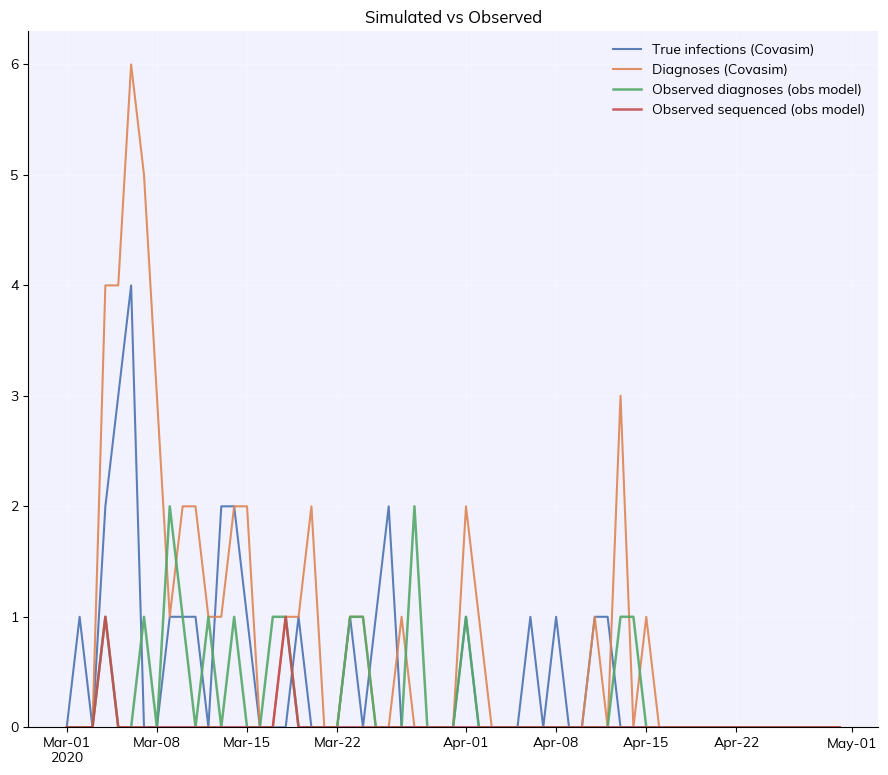

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.15 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.21 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.26 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.31 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.35 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.38 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.41 s)  •••••••••••••••••••• 100%

Simulation summary:
           33 cumulative infections
            0 cumulative reinfections
           33 cumulative infectious
           16 cumulative symptomatic cases
            4 cumulative severe cases
            1 cumulative critical cases
           33 cumulative recoveries
            0 cumulative deaths
      730,976 cumulative tests
           33 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
           33 cumulative isolated peo

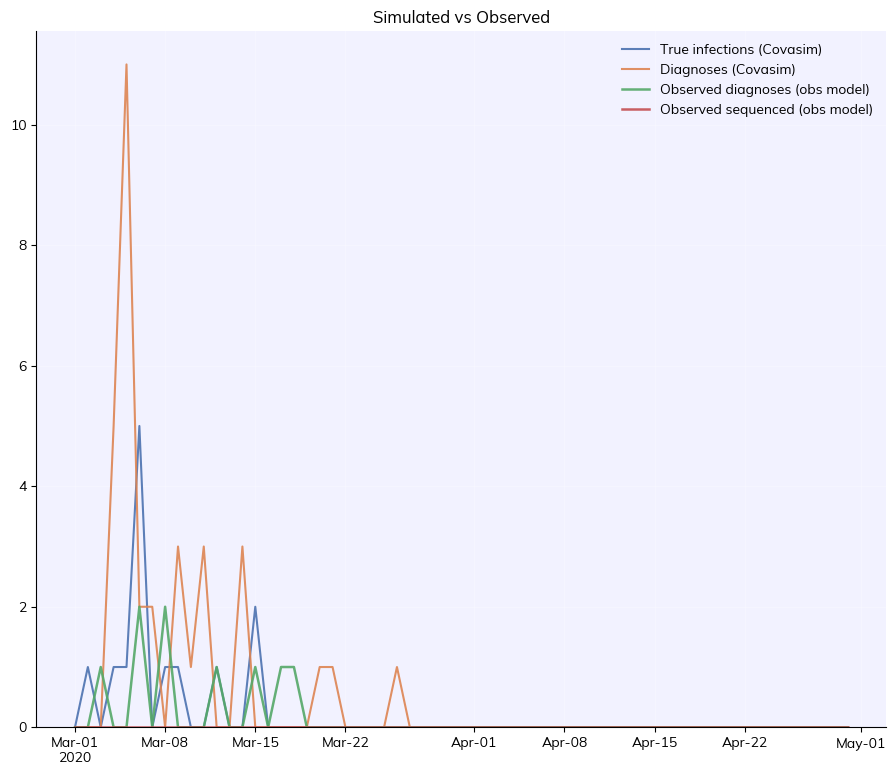

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.18 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.23 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.29 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.33 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.38 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.42 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.48 s)  •••••••••••••••••••• 100%

Simulation summary:
           65 cumulative infections
            0 cumulative reinfections
           63 cumulative infectious
           40 cumulative symptomatic cases
            6 cumulative severe cases
            0 cumulative critical cases
           57 cumulative recoveries
            0 cumulative deaths
      852,659 cumulative tests
           63 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
           63 cumulative isolated peo

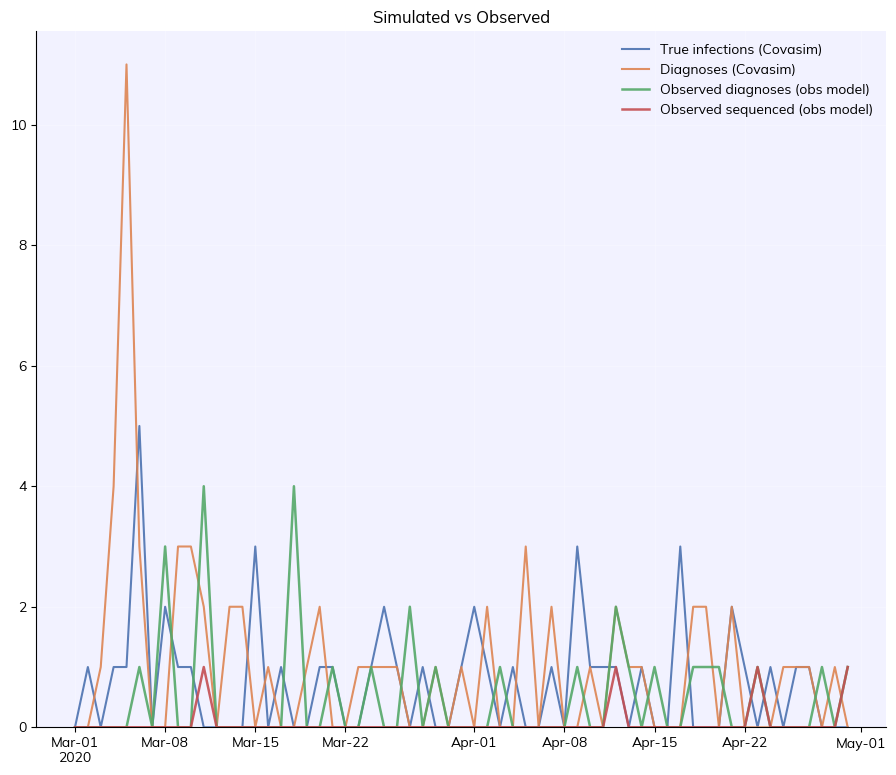

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.16 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.20 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.25 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.30 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.35 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.39 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.43 s)  •••••••••••••••••••• 100%

Simulation summary:
           44 cumulative infections
            0 cumulative reinfections
           44 cumulative infectious
           24 cumulative symptomatic cases
            5 cumulative severe cases
            1 cumulative critical cases
           44 cumulative recoveries
            0 cumulative deaths
      975,061 cumulative tests
           44 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
           44 cumulative isolated peo

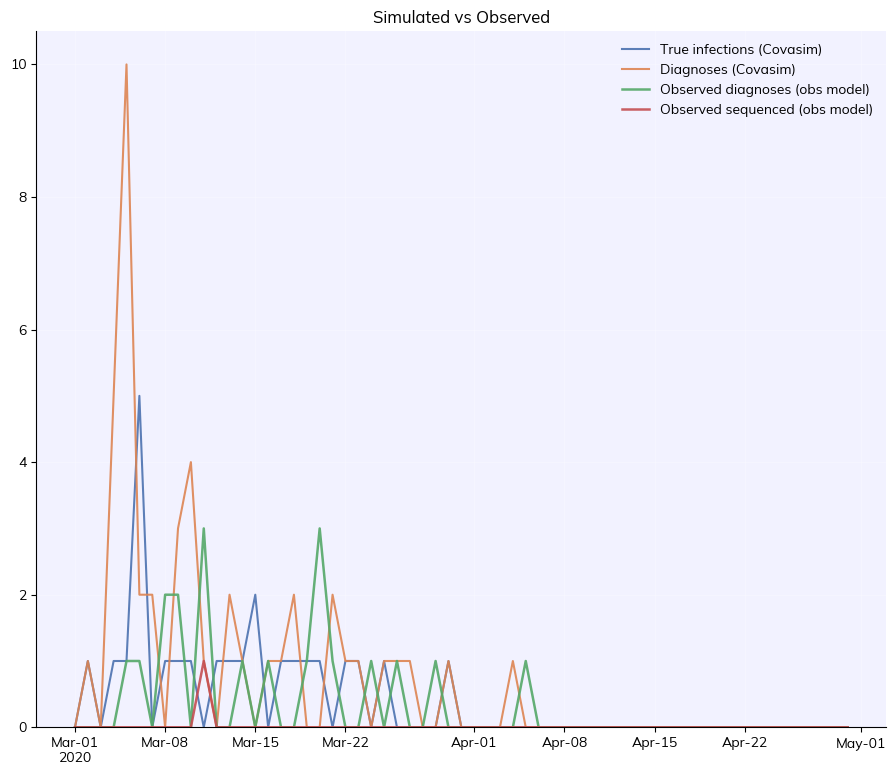

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.17 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.21 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.27 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.33 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.38 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.43 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.47 s)  •••••••••••••••••••• 100%

Simulation summary:
           49 cumulative infections
            0 cumulative reinfections
           49 cumulative infectious
           30 cumulative symptomatic cases
            5 cumulative severe cases
            1 cumulative critical cases
           49 cumulative recoveries
            0 cumulative deaths
    1,096,141 cumulative tests
           49 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
           49 cumulative isolated peo

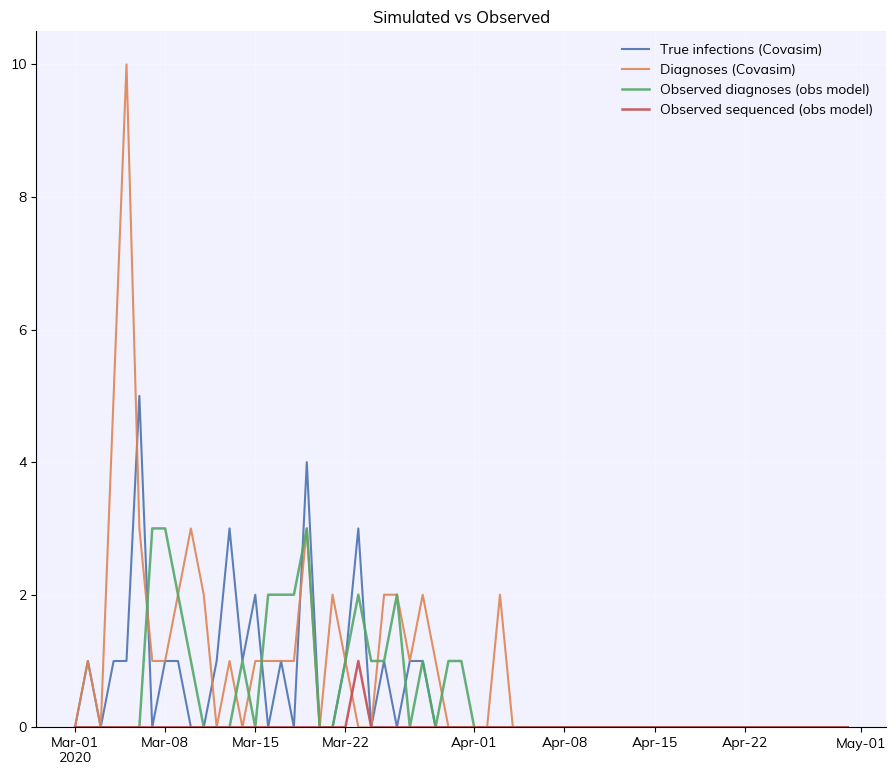

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.16 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.21 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.25 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.34 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.39 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.42 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.46 s)  •••••••••••••••••••• 100%

Simulation summary:
           34 cumulative infections
            1 cumulative reinfections
           34 cumulative infectious
           23 cumulative symptomatic cases
            4 cumulative severe cases
            0 cumulative critical cases
           34 cumulative recoveries
            0 cumulative deaths
    1,218,347 cumulative tests
           34 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
           34 cumulative isolated peo

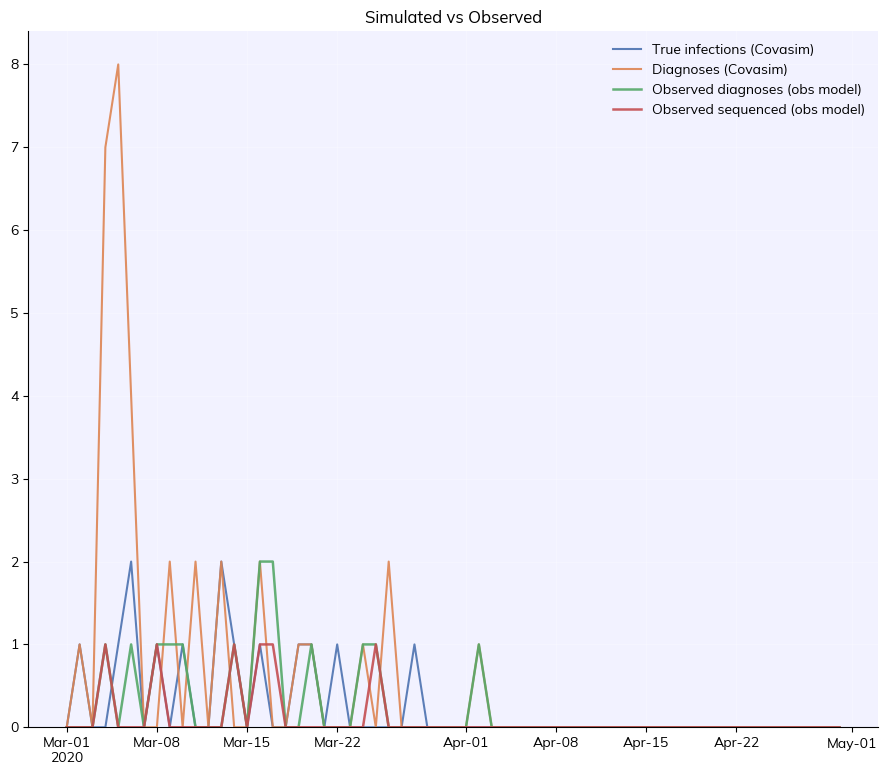

In [13]:
for i in range(10):
    p_test = (i+1) * 0.1
    interv = cv.test_prob(symp_prob=p_test, asymp_prob=p_test)
    sim = cv.Sim(interventions=[interv])
    sim.run()
    new_diag, new_seq = observe(sim, p_test, p_seq, [0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03])
    plot_sim_vs_observed(sim, new_diag, new_seq)